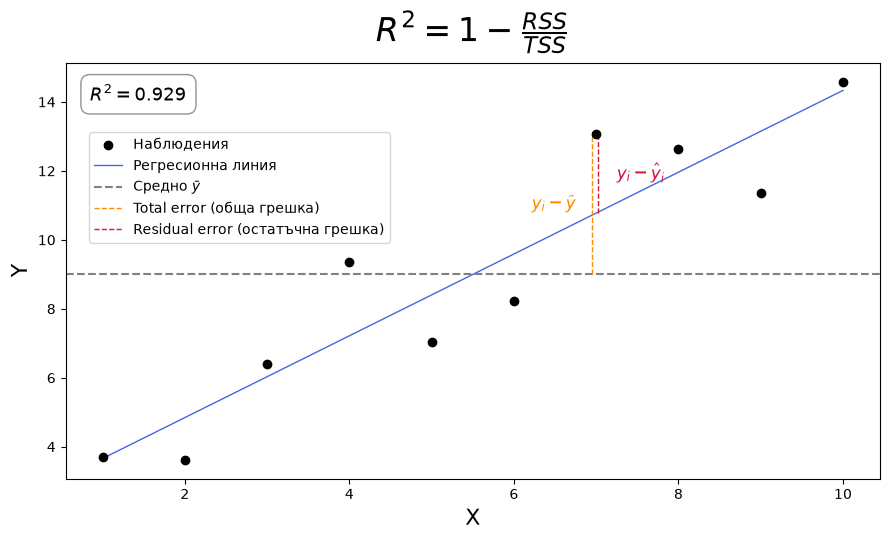

In [22]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate 10 data points with a bit more noise to get a larger residual error
x = np.linspace(1, 10, 10)
y = 1.2 * x + 1.5 + np.random.normal(0, 2.0, size=len(x))

coef = np.polyfit(x, y, 1)
y_hat = np.polyval(coef, x)
y_mean = y.mean()

# Select an observation with a noticeable/larger residual error and total error (e.g. index 6 -> x = 7)
i_obs = 6

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(x, y, color="black", zorder=4, label="Наблюдения")
ax.plot(x, y_hat, color="royalblue", linewidth=1, label="Регресионна линия")
ax.axhline(y_mean, color="gray", linestyle="--", label=r"Средно $\bar{y}$")

# Total error line (dashed): y_i - ȳ (Slightly offset to x for clarity if overlapping)
ax.vlines(
    x[i_obs] - 0.05, y_mean, y[i_obs],
    color="darkorange", linewidth=1, linestyle="--", label="Total error (обща грешка)", zorder=3
)
ax.text(
    x[i_obs] - 0.25, (y[i_obs] + y_mean) / 2,
    r"$y_i - \bar{y}$", color="darkorange", va="center", ha="right", fontsize=12, fontweight="bold"
)

# Residual error line (dashed): y_i - ŷ_i
ax.vlines(
    x[i_obs] + 0.025, y_hat[i_obs], y[i_obs],
    color="crimson", linewidth=1, linestyle="--", label="Residual error (остатъчна грешка)", zorder=3
)
ax.text(
    x[i_obs] + 0.25, (y[i_obs] + y_hat[i_obs]) / 2,
    r"$y_i - \hat{y}_i$", color="crimson", va="center", ha="left", fontsize=12, fontweight="bold"
)

# Title with formula R^2 = 1 - \frac{RSS}{TSS}
ax.set_title(r"$R^2 = 1 - \frac{RSS}{TSS}$", fontsize=24, pad=15)

ax.text(
    0.03, 0.95,
    f"$R^2 = {r2:.3f}$",
    transform=ax.transAxes,
    fontsize=13,
    va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray", boxstyle="round,pad=0.5")
)

ax.set_xlabel("X", fontsize=16)
ax.set_ylabel("Y", fontsize=16)
ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.85))

plt.tight_layout()
plt.savefig('./beamer/images/r_squared.png', dpi=1000)